In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from tomography import (
    make_3d_phantom,
    generate_projections,
    show_projections,
    reconstruct_volume,
    show_slices,
    render_3d,
    plot_ground_truth_slices,
    plot_comparison,
)

Creating 3D phantom...
Ground truth volume shape: (128, 128, 128)
Value range: [0.0000, 1.0000]


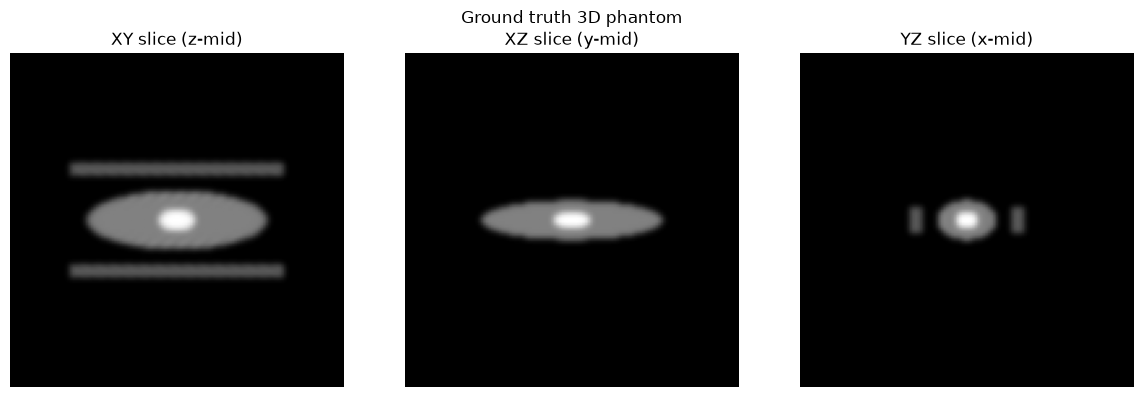

/Users/gehadsalem/Documents/coding/IMiP/IMiP_Week-3-Log_Off-Axis-Holography-Simulation/tomography.py:167: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


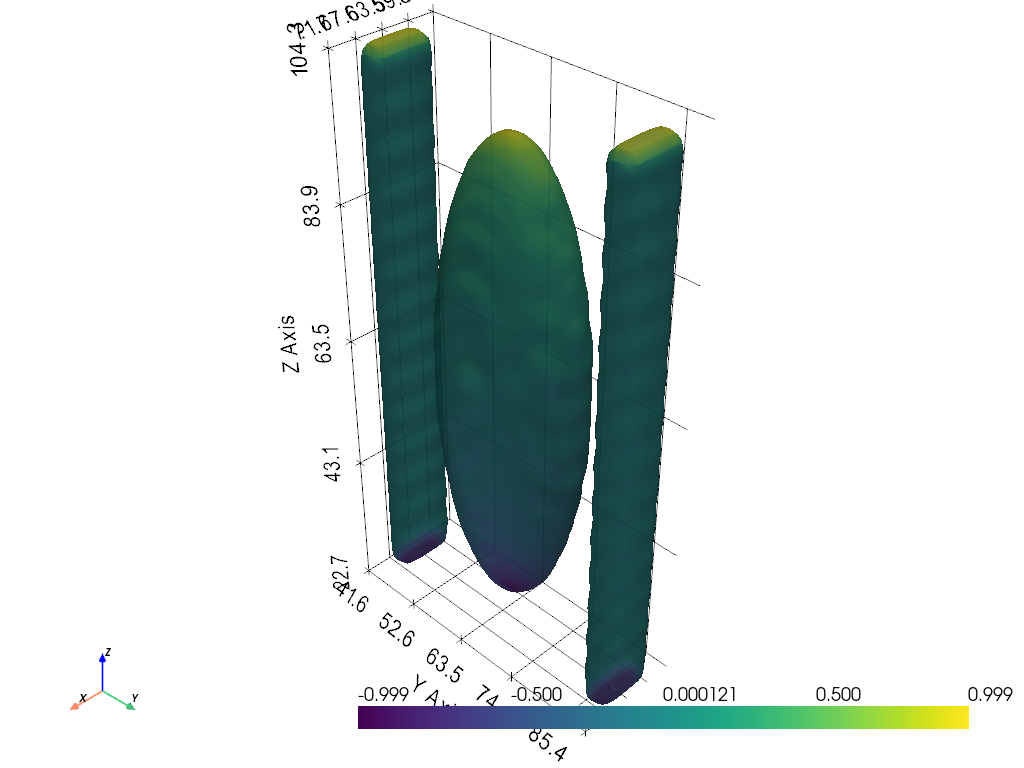

In [3]:
N = 128
n_angles = 60

print("Creating 3D phantom...")
volume_gt = make_3d_phantom(N)
print(f"Ground truth volume shape: {volume_gt.shape}")
print(f"Value range: [{volume_gt.min():.4f}, {volume_gt.max():.4f}]")

plot_ground_truth_slices(volume_gt, "Ground truth 3D phantom")
render_3d(volume_gt, threshold=0.2, opacity=0.8)

Generating phase projections...
Projections shape: (60, 128, 128)
Angles: 60 steps from 0.0° to 177.0°
Phase range: [-0.8460, 8.3343]


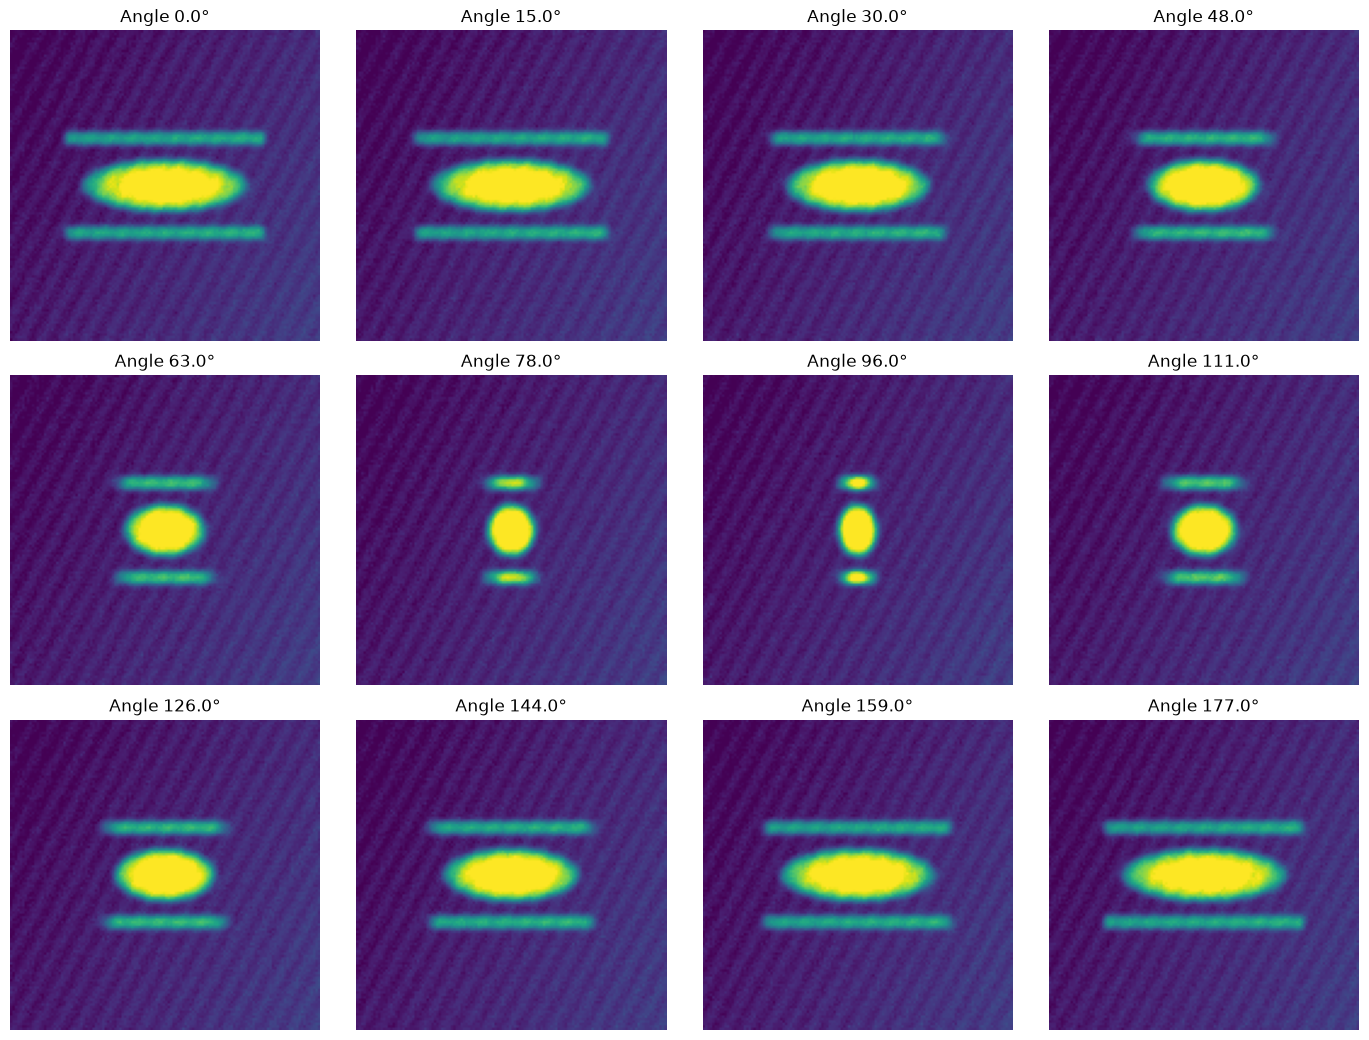

Saved projections.npy and angles.npy


In [4]:
print("Generating phase projections...")
projections, angles = generate_projections(volume_gt, num_angles=n_angles, max_phase_rad=8.0)

print(f"Projections shape: {projections.shape}")
print(f"Angles: {len(angles)} steps from {angles[0]:.1f}° to {angles[-1]:.1f}°")
print(f"Phase range: [{projections.min():.4f}, {projections.max():.4f}]")

show_projections(projections, angles, n_show=12)

np.save("projections.npy", projections)
np.save("angles.npy", angles)
print("Saved projections.npy and angles.npy")

Reconstructing 3D volume from projections...
Reconstructed volume shape: (128, 128, 128)


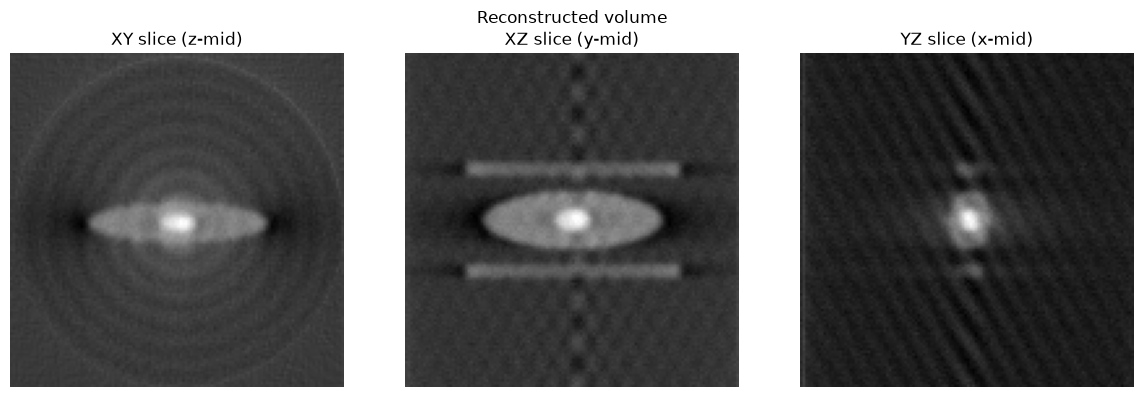

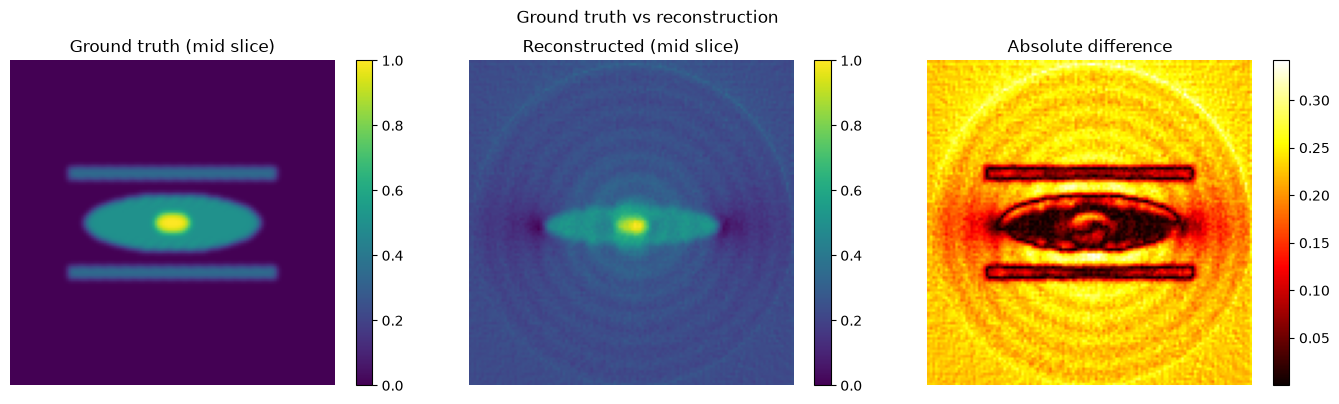

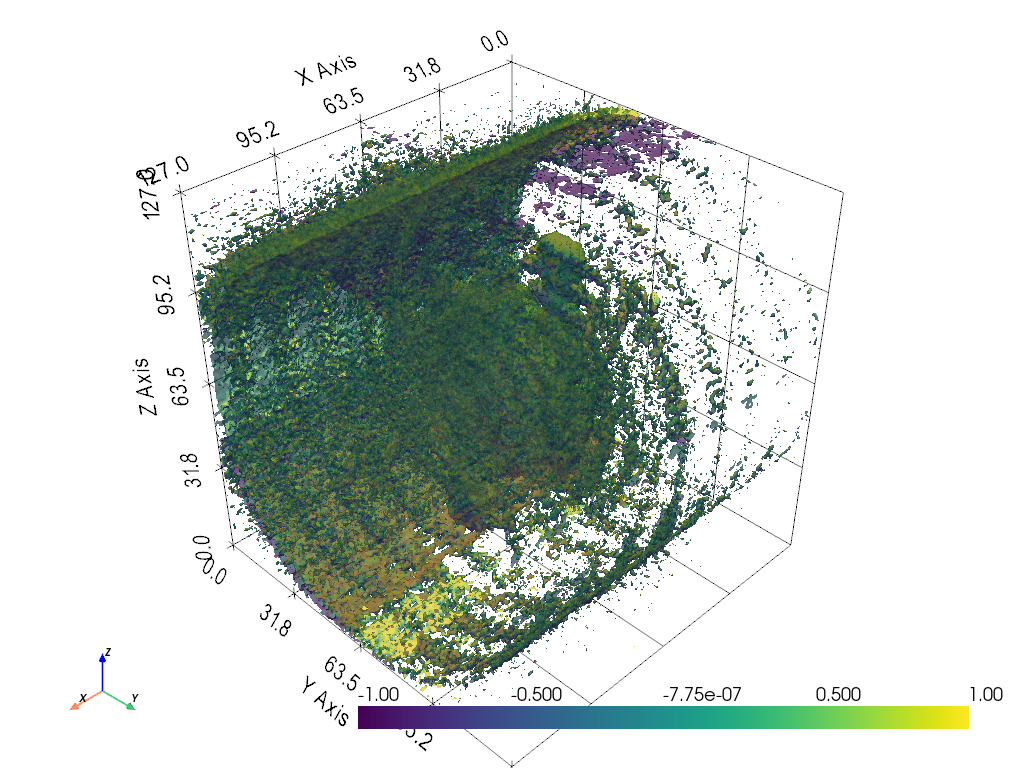

: 

In [ ]:
print("Reconstructing 3D volume from projections...")
reconstructed = reconstruct_volume(projections, angles)

print(f"Reconstructed volume shape: {reconstructed.shape}")

show_slices(reconstructed, "Reconstructed volume")

plot_comparison(volume_gt, reconstructed, "Ground truth vs reconstruction")

render_3d(reconstructed, threshold=0.25, opacity=0.7)